# Pipeline HerbalScan — Klasifikasi Daun Herbal

Notebook ini menjalankan seluruh pipeline:
1. Remove background (rembg)
2. Resize 224×224
3. Augmentasi Flip (H + V) + Rotasi
4. Build dataset final (no-bg & bg)
5. Visualisasi sampel
6. **Eksperimen 1** — Gabungan BG + NoBG, **daun sehat saja** (16 kelas), split 80:20 & 70:30
7. **Eksperimen 2** — Gabungan BG + NoBG, **semua kondisi termasuk rusak** (32 kelas), split 80:20 & 70:30
8. Ringkasan hasil

**Struktur kelas**:
- Eksperimen 1: `"Daun X NoBG"` dan `"Daun X BG"` → 8 spesies × 2 = 16 kelas
- Eksperimen 2: `"Daun X NoBG"`, `"Daun X BG"`, `"Daun X Rusak NoBG"`, `"Daun X Rusak BG"` → 8 spesies × 2 kondisi × 2 background = 32 kelas

**Augmentasi offline**: 250 H-Flip + 250 V-Flip + 500 Rotasi (0°/90°/180°/270°, 125 per sudut) → 1000 augmented per kelas  
Total per kelas: 300 original + 1000 augmented = **1300 gambar**  
**Augmentasi training**: Rotasi kotak acak (0°/90°/180°/270°) + H-Flip + GaussianBlur(k=3)

In [11]:
import json, time, random, shutil
import cv2
import torch
import torch.nn as nn
import numpy as np
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from rembg import remove as rembg_remove
from torchvision import datasets, transforms, models
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

BASE_DIR = Path().resolve()
if BASE_DIR.name == 'training':
    BASE_DIR = BASE_DIR.parent  
DATA_DIR      = BASE_DIR / "data"
NOBG_DIR      = DATA_DIR / "nobg"
RESIZED_DIR   = DATA_DIR / "resized"
AUGMENTED_DIR = DATA_DIR / "augmented"
FINAL_NOBG    = DATA_DIR / "final"
FINAL_BG      = DATA_DIR / "final bg"
MODEL_DIR     = BASE_DIR / "model"
RESULT_DIR    = BASE_DIR / "results"

BATCH_SIZE = 16
EPOCHS     = 30
LR         = 0.001
SEED       = 42
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for d in [MODEL_DIR, RESULT_DIR]:
    d.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")

Device: cpu


## Transforms & Helper Functions

In [12]:
# ── Transforms ────────────────────────────────────────────────────────────────
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda img: TF.rotate(img, random.choice([0, 90, 180, 270]))),
    transforms.RandomHorizontalFlip(),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


# ── CombinedTaggedDataset ─────────────────────────────────────────────────────
class CombinedTaggedDataset(Dataset):
    def __init__(self, nobg_root: Path, bg_root: Path, include_rusak: bool = True):
        from torchvision.datasets import ImageFolder as _IF
        nobg_base = _IF(str(nobg_root))
        bg_base   = _IF(str(bg_root))

        nobg_tagged = {c: f"{c} NoBG" for c in nobg_base.classes}
        bg_tagged   = {c: f"{c} BG"   for c in bg_base.classes}

        all_class_names: list[str] = []
        for orig, tagged in nobg_tagged.items():
            if (include_rusak or "Rusak" not in orig) and tagged not in all_class_names:
                all_class_names.append(tagged)
        for orig, tagged in bg_tagged.items():
            if (include_rusak or "Rusak" not in orig) and tagged not in all_class_names:
                all_class_names.append(tagged)

        self.classes      = sorted(all_class_names)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples: list[tuple[str, int]] = []
        for img_path, orig_label in nobg_base.samples:
            tagged = nobg_tagged[nobg_base.classes[orig_label]]
            if tagged in self.class_to_idx:
                self.samples.append((img_path, self.class_to_idx[tagged]))
        for img_path, orig_label in bg_base.samples:
            tagged = bg_tagged[bg_base.classes[orig_label]]
            if tagged in self.class_to_idx:
                self.samples.append((img_path, self.class_to_idx[tagged]))

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, label = self.samples[idx]
        return Image.open(img_path).convert("RGB"), label


# ── TransformWrapper ──────────────────────────────────────────────────────────
class TransformWrapper(Dataset):
    def __init__(self, subset: Subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


# ── Helper confusion matrix per grup ─────────────────────────────────────────
def _species_name(class_name: str) -> str:
    return (class_name
            .replace(" Rusak NoBG", "").replace(" Rusak BG", "")
            .replace(" NoBG", "").replace(" BG", "")
            .replace(" Rusak", "").strip())

def _get_group(class_name: str) -> str:
    is_rusak = "Rusak" in class_name
    is_nobg  = class_name.endswith("NoBG")
    if   not is_rusak and not is_nobg: return "Sehat BG"
    elif not is_rusak and     is_nobg: return "Sehat NoBG"
    elif     is_rusak and not is_nobg: return "Rusak BG"
    else:                              return "Rusak NoBG"

def plot_split_cm(y_true, y_pred, class_names, exp_tag, train_pct, exp_label, label_str):
    group_of   = {cn: _get_group(cn) for cn in class_names}
    groups     = sorted(set(group_of.values()))
    n_groups   = len(groups)
    n_cols_fig = 2
    n_rows_fig = (n_groups + 1) // 2

    fig, axes = plt.subplots(n_rows_fig, n_cols_fig,
                             figsize=(n_cols_fig * 9, n_rows_fig * 7.5))
    axes = axes.flatten()

    for ax_idx, group in enumerate(groups):
        grp_classes  = [cn for cn in class_names if group_of[cn] == group]
        grp_idx_map  = {class_names.index(cn): i for i, cn in enumerate(grp_classes)}
        species_lbls = [_species_name(cn) for cn in grp_classes]
        n            = len(grp_classes)

        mask     = [i for i, t in enumerate(y_true) if t in grp_idx_map]
        sub_true = [grp_idx_map[y_true[i]] for i in mask]
        sub_pred = [grp_idx_map.get(y_pred[i], n) for i in mask]

        has_other = any(p == n for p in sub_pred)
        n_pred    = n + 1 if has_other else n
        col_lbls  = species_lbls + (["[Lainnya]"] if has_other else [])

        cm  = confusion_matrix(sub_true, sub_pred, labels=list(range(n_pred)))
        acc = sum(t == p for t, p in zip(sub_true, sub_pred)) / len(sub_true) if sub_true else 0

        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=col_lbls, yticklabels=species_lbls,
                    ax=axes[ax_idx], annot_kws={"size": 8})
        axes[ax_idx].set_title(f"{group}  |  Acc: {acc:.2%}", fontsize=11, fontweight="bold")
        axes[ax_idx].set_xlabel("Predicted", fontsize=9)
        axes[ax_idx].set_ylabel("True",      fontsize=9)
        axes[ax_idx].tick_params(axis="x", rotation=45, labelsize=8)
        axes[ax_idx].tick_params(axis="y", rotation=0,  labelsize=8)

    for ax_idx in range(n_groups, len(axes)):
        axes[ax_idx].set_visible(False)

    fig.suptitle(f"Confusion Matrix per Grup — {exp_label}\nSplit {label_str}", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"cm_split_{exp_tag}_{train_pct}.png", dpi=150, bbox_inches="tight")
    plt.show()


def folder_ready(path: Path, min_files: int = 1) -> bool:
    return path.exists() and sum(1 for _ in path.rglob("*") if _.is_file()) >= min_files

print("Transforms & helpers siap.")


Transforms & helpers siap.


## 1. Remove Background (rembg)

In [13]:
if folder_ready(NOBG_DIR):
    print(f"Skip — {NOBG_DIR} sudah ada.")
else:
    NOBG_DIR.mkdir(parents=True, exist_ok=True)
    raw_dir = DATA_DIR / "raw"
    exts = {".jpg", ".jpeg", ".png"}
    total = 0
    for cls_dir in sorted(raw_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = NOBG_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            with open(img_file, "rb") as f:
                result = rembg_remove(f.read())
            out_path = out_cls / (img_file.stem + ".png")
            out_path.write_bytes(result)
            total += 1
    print(f"Remove background selesai — {total} gambar → {NOBG_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\nobg sudah ada.


## 2. Resize 224×224

In [14]:
if folder_ready(RESIZED_DIR):
    print(f"Skip — {RESIZED_DIR} sudah ada.")
else:
    RESIZED_DIR.mkdir(parents=True, exist_ok=True)
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    total = 0
    for cls_dir in sorted(NOBG_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = RESIZED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        for img_file in cls_dir.iterdir():
            if img_file.suffix.lower() not in exts:
                continue
            img = cv2.imread(str(img_file), cv2.IMREAD_UNCHANGED)
            if img is None:
                continue
            img_resized = cv2.resize(img, (224, 224))
            cv2.imwrite(str(out_cls / img_file.name), img_resized)
            total += 1
    print(f"Resize selesai — {total} gambar → {RESIZED_DIR}")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\resized sudah ada.


## 3. Augmentasi (Flip + Rotasi)

In [15]:
if folder_ready(AUGMENTED_DIR):
    print(f"Skip — {AUGMENTED_DIR} sudah ada.")
else:
    AUGMENTED_DIR.mkdir(parents=True, exist_ok=True)
    AUG_H_FLIP    = 250
    AUG_V_FLIP    = 250
    ROTATE_ANGLES = [0, 90, 180, 270]
    ROT_PER_ANGLE = 125
    exts = {".jpg", ".jpeg", ".png"}
    total = 0

    def _rotate(img, angle):
        if angle == 0:
            return img.copy()
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    for cls_dir in sorted(RESIZED_DIR.iterdir()):
        if not cls_dir.is_dir():
            continue
        out_cls = AUGMENTED_DIR / cls_dir.name
        out_cls.mkdir(exist_ok=True)
        images = [p for p in cls_dir.iterdir() if p.suffix.lower() in exts]
        if not images:
            continue

        # Tahap 1: Flip dari gambar original resized
        flipped_paths = []

        for i in range(AUG_H_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                out_path = out_cls / f"{cls_dir.name}_hflip_{i}.jpg"
                cv2.imwrite(str(out_path), cv2.flip(img, 1))
                flipped_paths.append(out_path)
                total += 1

        for i in range(AUG_V_FLIP):
            img = cv2.imread(str(random.choice(images)))
            if img is not None:
                out_path = out_cls / f"{cls_dir.name}_vflip_{i}.jpg"
                cv2.imwrite(str(out_path), cv2.flip(img, 0))
                flipped_paths.append(out_path)
                total += 1

        # Tahap 2: Rotasi dari gambar hasil flip (4 sudut x 125 = 500)
        rot_idx = 0
        for angle in ROTATE_ANGLES:
            for i in range(ROT_PER_ANGLE):
                img = cv2.imread(str(random.choice(flipped_paths)))
                if img is not None:
                    out_path = out_cls / f"{cls_dir.name}_rot{angle}_{rot_idx}.jpg"
                    cv2.imwrite(str(out_path), _rotate(img, angle))
                    rot_idx += 1
                    total += 1

        flip_total = AUG_H_FLIP + AUG_V_FLIP
        rot_total  = len(ROTATE_ANGLES) * ROT_PER_ANGLE
        print(f"  {cls_dir.name}: {flip_total} flip + {rot_total} rotasi = {flip_total + rot_total} augmented")

    print(f"Augmentasi selesai — {total} gambar → {AUGMENTED_DIR}")
    print(f"Per kelas: 300 original + 500 flip + 500 rotasi = 1300 total")

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\augmented sudah ada.


## 4. Build Final Dataset (No-BG & BG)

Menggabungkan `data/resized` + `data/augmented` → `data/final` (no-bg)
Dataset `data/final bg` diasumsikan sudah tersedia (gambar asli dengan background).

In [16]:
def build_nobg_final():
    if folder_ready(FINAL_NOBG):
        print(f"Skip — {FINAL_NOBG} sudah ada.")
        return
    FINAL_NOBG.mkdir(parents=True, exist_ok=True)
    sources = [RESIZED_DIR, AUGMENTED_DIR]
    total = 0
    for src in sources:
        if not src.exists():
            print(f"  Warning: {src} tidak ditemukan, dilewati")
            continue
        for cls_dir in sorted(src.iterdir()):
            if not cls_dir.is_dir():
                continue
            out_cls = FINAL_NOBG / cls_dir.name
            out_cls.mkdir(exist_ok=True)
            for img_file in cls_dir.iterdir():
                if img_file.is_file():
                    dst = out_cls / f"{src.name}_{img_file.name}"
                    shutil.copy2(img_file, dst)
                    total += 1
    print(f"Build final no-bg selesai — {total} file → {FINAL_NOBG}")

build_nobg_final()

Skip — C:\Users\dvsw1\Documents\Kuliah\Kuliah\Skripsi\Code\data\final sudah ada.


## 5. Eksperimen 1 — Gabungan BG + NoBG (Daun Sehat Saja)

Menggabungkan dataset `data/final` (NoBG) dan `data/final bg` (BG).
Kelas **Rusak dikecualikan** — hanya daun sehat yang dilatih.
Nama kelas diberi tag: *"Daun X NoBG"* dan *"Daun X BG"* → **16 kelas** (8 spesies × 2 background).
Split: 80:20 dan 70:30 (Stratified Shuffle Split).


EKSPERIMEN 1 — SEHAT (BG + NOBG) | Split 80:20
Kelas: 16 | Train: 16640 | Val: 4160
  Epoch 1/30  train_loss=1.7953  train_acc=0.8242  val_loss=1.2561  val_acc=0.9149
  Epoch 2/30  train_loss=0.9070  train_acc=0.9639  val_loss=0.7769  val_acc=0.9445
  Epoch 3/30  train_loss=0.5670  train_acc=0.9770  val_loss=0.5042  val_acc=0.9666
  Epoch 4/30  train_loss=0.3926  train_acc=0.9839  val_loss=0.4255  val_acc=0.9724
  Epoch 5/30  train_loss=0.2929  train_acc=0.9872  val_loss=0.3095  val_acc=0.9885
  Epoch 6/30  train_loss=0.2284  train_acc=0.9889  val_loss=0.2595  val_acc=0.9808
  Epoch 7/30  train_loss=0.1820  train_acc=0.9907  val_loss=0.1718  val_acc=0.9942
  Epoch 8/30  train_loss=0.1464  train_acc=0.9929  val_loss=0.1448  val_acc=0.9938
  Epoch 9/30  train_loss=0.1221  train_acc=0.9942  val_loss=0.1277  val_acc=0.9940
  Epoch 10/30  train_loss=0.1056  train_acc=0.9945  val_loss=0.1057  val_acc=0.9959
  Epoch 11/30  train_loss=0.0904  train_acc=0.9951  val_loss=0.0929  val_acc=0.9974


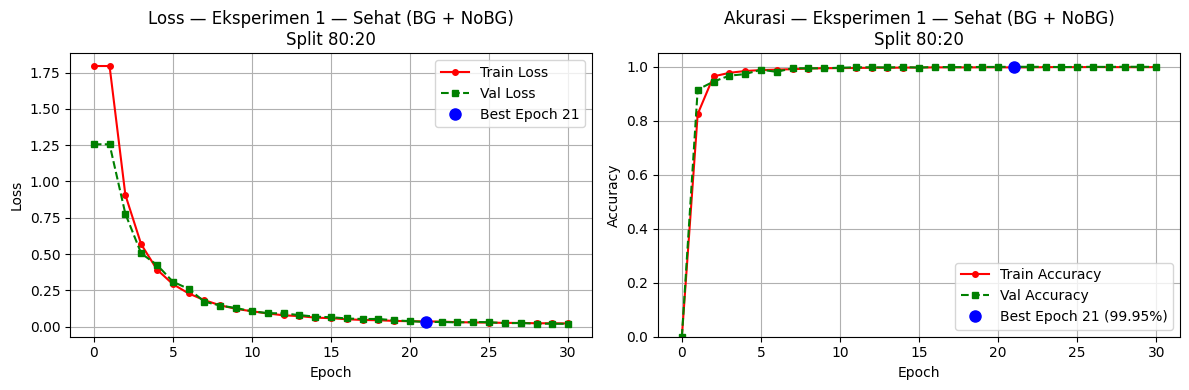

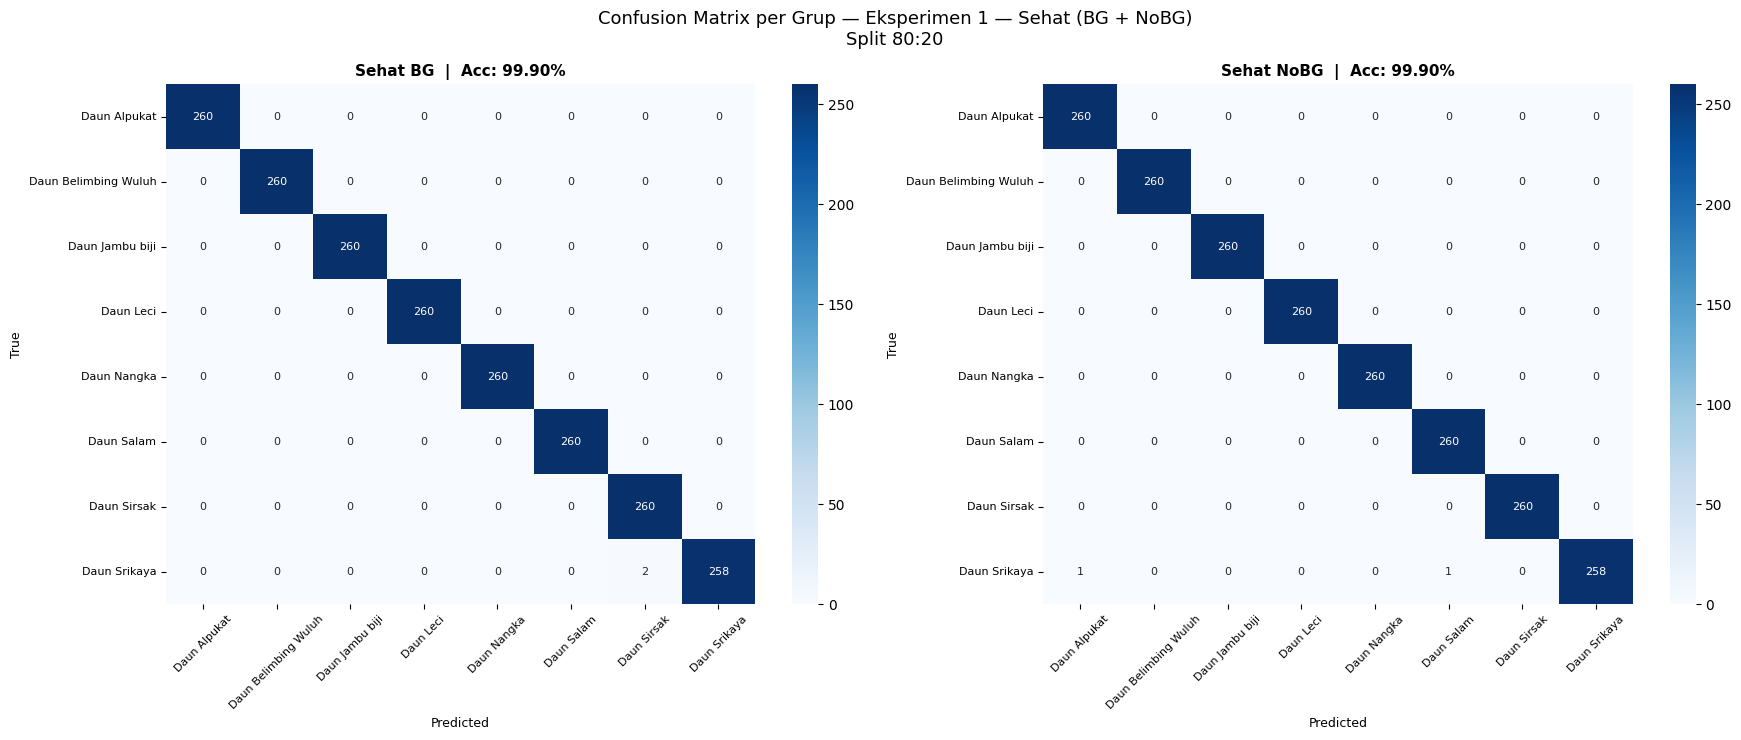

  Saved -> results_exp1_80.json

EKSPERIMEN 1 — SEHAT (BG + NOBG) | Split 70:30
Kelas: 16 | Train: 14560 | Val: 6240
  Epoch 1/30  train_loss=1.8693  train_acc=0.8180  val_loss=1.3361  val_acc=0.9240
  Epoch 2/30  train_loss=1.0004  train_acc=0.9622  val_loss=0.8471  val_acc=0.9346
  Epoch 3/30  train_loss=0.6513  train_acc=0.9706  val_loss=0.6027  val_acc=0.9563
  Epoch 4/30  train_loss=0.4532  train_acc=0.9820  val_loss=0.4559  val_acc=0.9787
  Epoch 5/30  train_loss=0.3425  train_acc=0.9870  val_loss=0.3535  val_acc=0.9827
  Epoch 6/30  train_loss=0.2705  train_acc=0.9859  val_loss=0.2609  val_acc=0.9891
  Epoch 7/30  train_loss=0.2171  train_acc=0.9888  val_loss=0.2565  val_acc=0.9913
  Epoch 8/30  train_loss=0.1766  train_acc=0.9932  val_loss=0.1697  val_acc=0.9921
  Epoch 9/30  train_loss=0.1481  train_acc=0.9927  val_loss=0.1699  val_acc=0.9925
  Epoch 10/30  train_loss=0.1269  train_acc=0.9933  val_loss=0.1393  val_acc=0.9944
  Epoch 11/30  train_loss=0.1094  train_acc=0.9940  

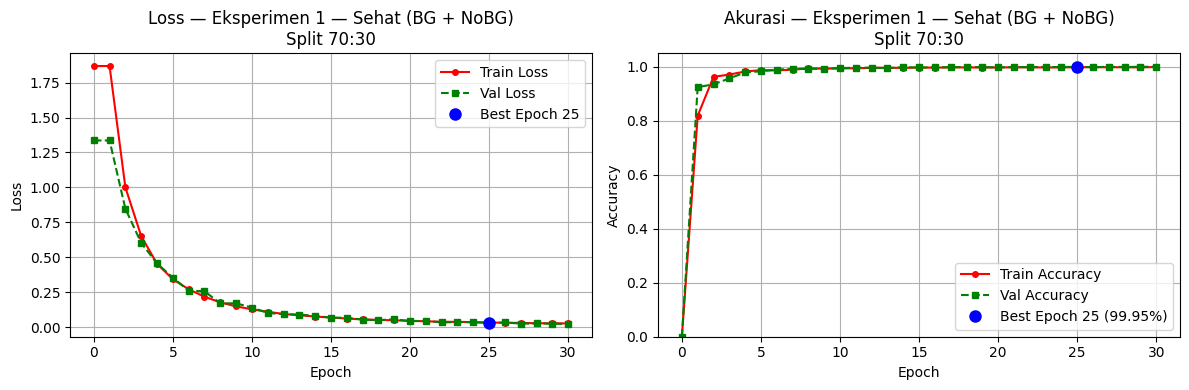

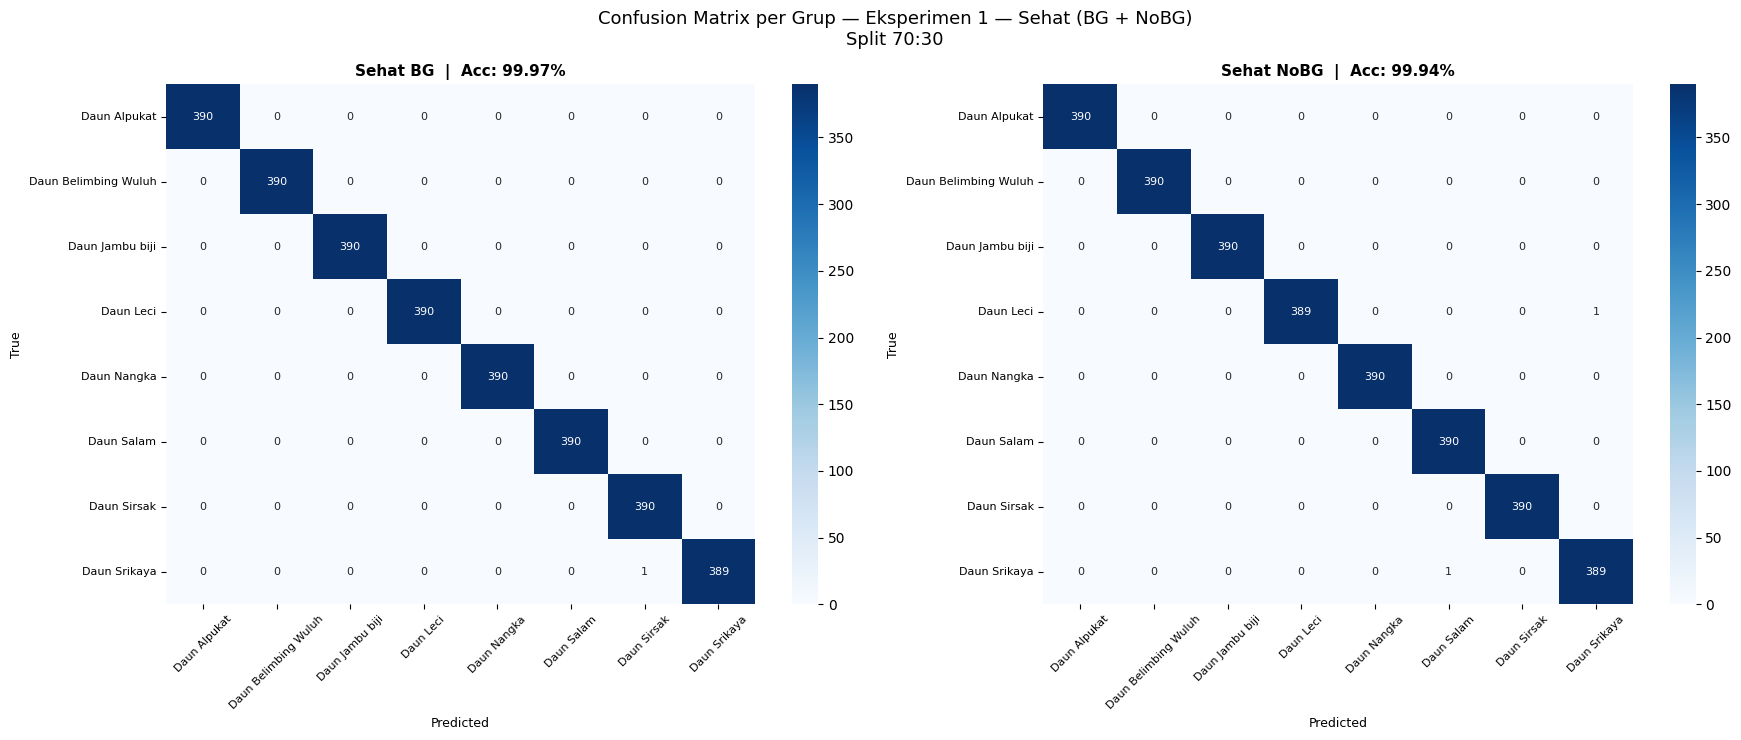

  Saved -> results_exp1_70.json


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def train_and_evaluate(
    exp_tag: str,
    exp_label: str,
    include_rusak: bool,
    split_ratio: float,
):
    test_ratio = round(1.0 - split_ratio, 10)
    train_pct  = round(split_ratio * 100)
    test_pct   = 100 - train_pct
    label_str  = f"{train_pct}:{test_pct}"

    full_ds     = CombinedTaggedDataset(FINAL_NOBG, FINAL_BG, include_rusak=include_rusak)
    class_names = full_ds.classes
    num_classes = len(class_names)
    all_labels  = np.array([lbl for _, lbl in full_ds.samples])

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio, random_state=SEED)
    train_idx, val_idx = next(splitter.split(np.zeros(len(all_labels)), all_labels))

    train_loader = DataLoader(
        TransformWrapper(Subset(full_ds, train_idx), transform_train),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    )
    val_loader = DataLoader(
        TransformWrapper(Subset(full_ds, val_idx), transform_val),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
    )

    print(f"\n{'='*60}")
    print(f"{exp_label.upper()} | Split {label_str}")
    print(f"Kelas: {num_classes} | Train: {len(train_idx)} | Val: {len(val_idx)}")

    model = models.shufflenet_v2_x1_0(
        weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    )
    for p in model.parameters():
        p.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

    history = []
    start   = time.time()

    for epoch in range(EPOCHS):
        model.train()
        running_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out  = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss  += loss.item()
            _, preds       = torch.max(out, 1)
            train_correct += (preds == y).sum().item()
            train_total   += y.size(0)
        avg_loss  = running_loss / len(train_loader)
        train_acc = train_correct / train_total

        model.eval()
        correct, total, val_loss = 0, 0, 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out      = model(x)
                val_loss += criterion(out, y).item()
                _, preds  = torch.max(out, 1)
                correct  += (preds == y).sum().item()
                total    += y.size(0)
        val_acc      = correct / total
        avg_val_loss = val_loss / len(val_loader)

        history.append({
            "epoch":      epoch + 1,
            "train_loss": round(avg_loss, 4),
            "train_acc":  round(train_acc, 4),
            "val_loss":   round(avg_val_loss, 4),
            "val_acc":    round(val_acc, 4),
        })
        print(f"  Epoch {epoch+1}/{EPOCHS}  train_loss={avg_loss:.4f}  train_acc={train_acc:.4f}"
              f"  val_loss={avg_val_loss:.4f}  val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"  Selesai dalam {int(elapsed//60)}m {int(elapsed%60)}s")

    # ── Evaluasi akhir ────────────────────────────────────────────────────────
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            _, preds = torch.max(model(x.to(DEVICE)), 1)
            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

    print(f"\n  {'Metric':<12} {'Score':>8}")
    print(f"  {'-'*22}")
    print(f"  {'Accuracy':<12} {acc:>8.4f}")
    print(f"  {'Precision':<12} {prec:>8.4f}")
    print(f"  {'Recall':<12} {rec:>8.4f}")
    print(f"  {'F1-Score':<12} {f1:>8.4f}")

    best = max(history, key=lambda h: h["val_acc"])

    # ── Plot loss & akurasi ───────────────────────────────────────────────────
    ep_plot         = [0] + [h["epoch"]      for h in history]
    train_loss_plot = [history[0]["train_loss"]] + [h["train_loss"] for h in history]
    val_loss_plot   = [history[0]["val_loss"]]   + [h["val_loss"]   for h in history]
    train_acc_plot  = [0] + [h["train_acc"] for h in history]
    val_acc_plot    = [0] + [h["val_acc"]   for h in history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(ep_plot, train_loss_plot, "r-o",  markersize=4, label="Train Loss")
    ax1.plot(ep_plot, val_loss_plot,   "g--s", markersize=4, label="Val Loss")
    ax1.plot(best["epoch"], best["val_loss"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']}")
    ax1.set_title(f"Loss — {exp_label}\nSplit {label_str}")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(ep_plot, train_acc_plot, "r-o",  markersize=4, label="Train Accuracy")
    ax2.plot(ep_plot, val_acc_plot,   "g--s", markersize=4, label="Val Accuracy")
    ax2.plot(best["epoch"], best["val_acc"], "bo", markersize=8,
             label=f"Best Epoch {best['epoch']} ({best['val_acc']:.2%})")
    ax2.set_title(f"Akurasi — {exp_label}\nSplit {label_str}")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"plot_{exp_tag}_{train_pct}.png", dpi=120, bbox_inches="tight")
    plt.show()

    # ── Confusion matrix terpisah per grup ───────────────────────────────────
    plot_split_cm(y_true, y_pred, class_names,
                  exp_tag, train_pct, exp_label, label_str)

    # ── Simpan model & JSON (UTF-8) ───────────────────────────────────────────
    torch.save(model.state_dict(), MODEL_DIR / f"shufflenet_{exp_tag}_{train_pct}.pth")
    json_path = RESULT_DIR / f"results_{exp_tag}_{train_pct}.json"
    json_path.write_text(json.dumps({
        "experiment":            exp_label,
        "tag":                   exp_tag,
        "split":                 label_str,
        "dataset_nobg":          str(FINAL_NOBG),
        "dataset_bg":            str(FINAL_BG),
        "include_rusak":         include_rusak,
        "num_classes":           num_classes,
        "class_names":           class_names,
        "epochs":                EPOCHS,
        "training_time_sec":     round(elapsed, 2),
        "accuracy":              round(acc, 4),
        "precision_weighted":    round(prec, 4),
        "recall_weighted":       round(rec, 4),
        "f1_weighted":           round(f1, 4),
        "best_epoch":            best["epoch"],
        "best_val_accuracy":     best["val_acc"],
        "final_train_accuracy":  history[-1]["train_acc"],
        "final_val_accuracy":    history[-1]["val_acc"],
        "classification_report": report,
        "training_history":      history,
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"  Saved -> {json_path.name}")


# Jalankan Eksperimen 1 (sehat saja)
for ratio in [0.8, 0.7]:
    train_and_evaluate(
        exp_tag="exp1",
        exp_label="Eksperimen 1 — Sehat (BG + NoBG)",
        include_rusak=False,
        split_ratio=ratio,
    )


## 6. Eksperimen 2 — Gabungan BG + NoBG (Semua Kondisi: Sehat + Rusak)

Menggabungkan dataset `data/final` (NoBG) dan `data/final bg` (BG).
**Semua kelas dilatih**, termasuk daun rusak.
Nama kelas: *"Daun X BG"*, *"Daun X NoBG"*, *"Daun X Rusak BG"*, *"Daun X Rusak NoBG"* → **32 kelas**.
Confusion matrix menampilkan label rusak secara terpisah berdasarkan kondisi background.


EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 80:20
Kelas: 32 | Train: 33280 | Val: 8320
  Epoch 1/30  train_loss=2.0263  train_acc=0.8178  val_loss=1.3131  val_acc=0.9383
  Epoch 2/30  train_loss=0.9075  train_acc=0.9610  val_loss=0.8169  val_acc=0.9470
  Epoch 3/30  train_loss=0.5342  train_acc=0.9746  val_loss=0.5119  val_acc=0.9648
  Epoch 4/30  train_loss=0.3577  train_acc=0.9806  val_loss=0.3949  val_acc=0.9748
  Epoch 5/30  train_loss=0.2608  train_acc=0.9854  val_loss=0.2649  val_acc=0.9858
  Epoch 6/30  train_loss=0.2006  train_acc=0.9879  val_loss=0.2278  val_acc=0.9895
  Epoch 7/30  train_loss=0.1606  train_acc=0.9900  val_loss=0.1935  val_acc=0.9897
  Epoch 8/30  train_loss=0.1306  train_acc=0.9917  val_loss=0.1449  val_acc=0.9918
  Epoch 9/30  train_loss=0.1124  train_acc=0.9918  val_loss=0.1576  val_acc=0.9924
  Epoch 10/30  train_loss=0.0953  train_acc=0.9931  val_loss=0.1066  val_acc=0.9960
  Epoch 11/30  train_loss=0.0822  train_acc=0.9945  val_loss=0.0998 

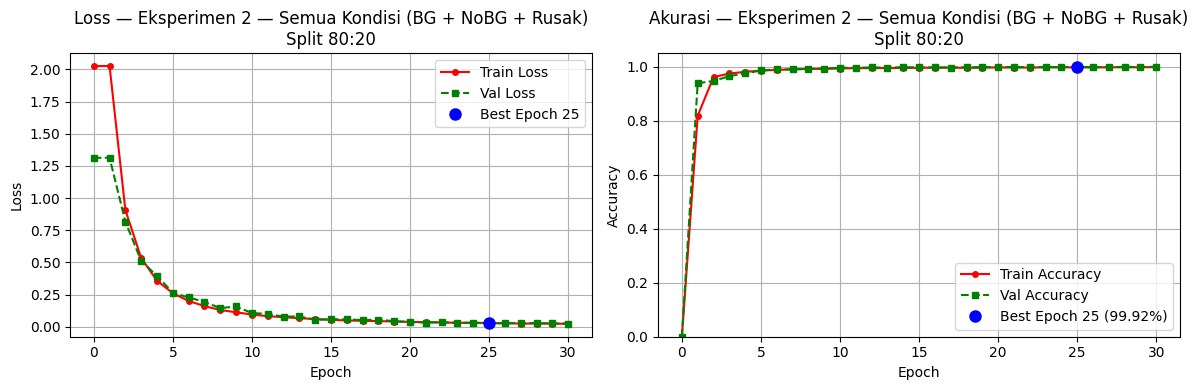

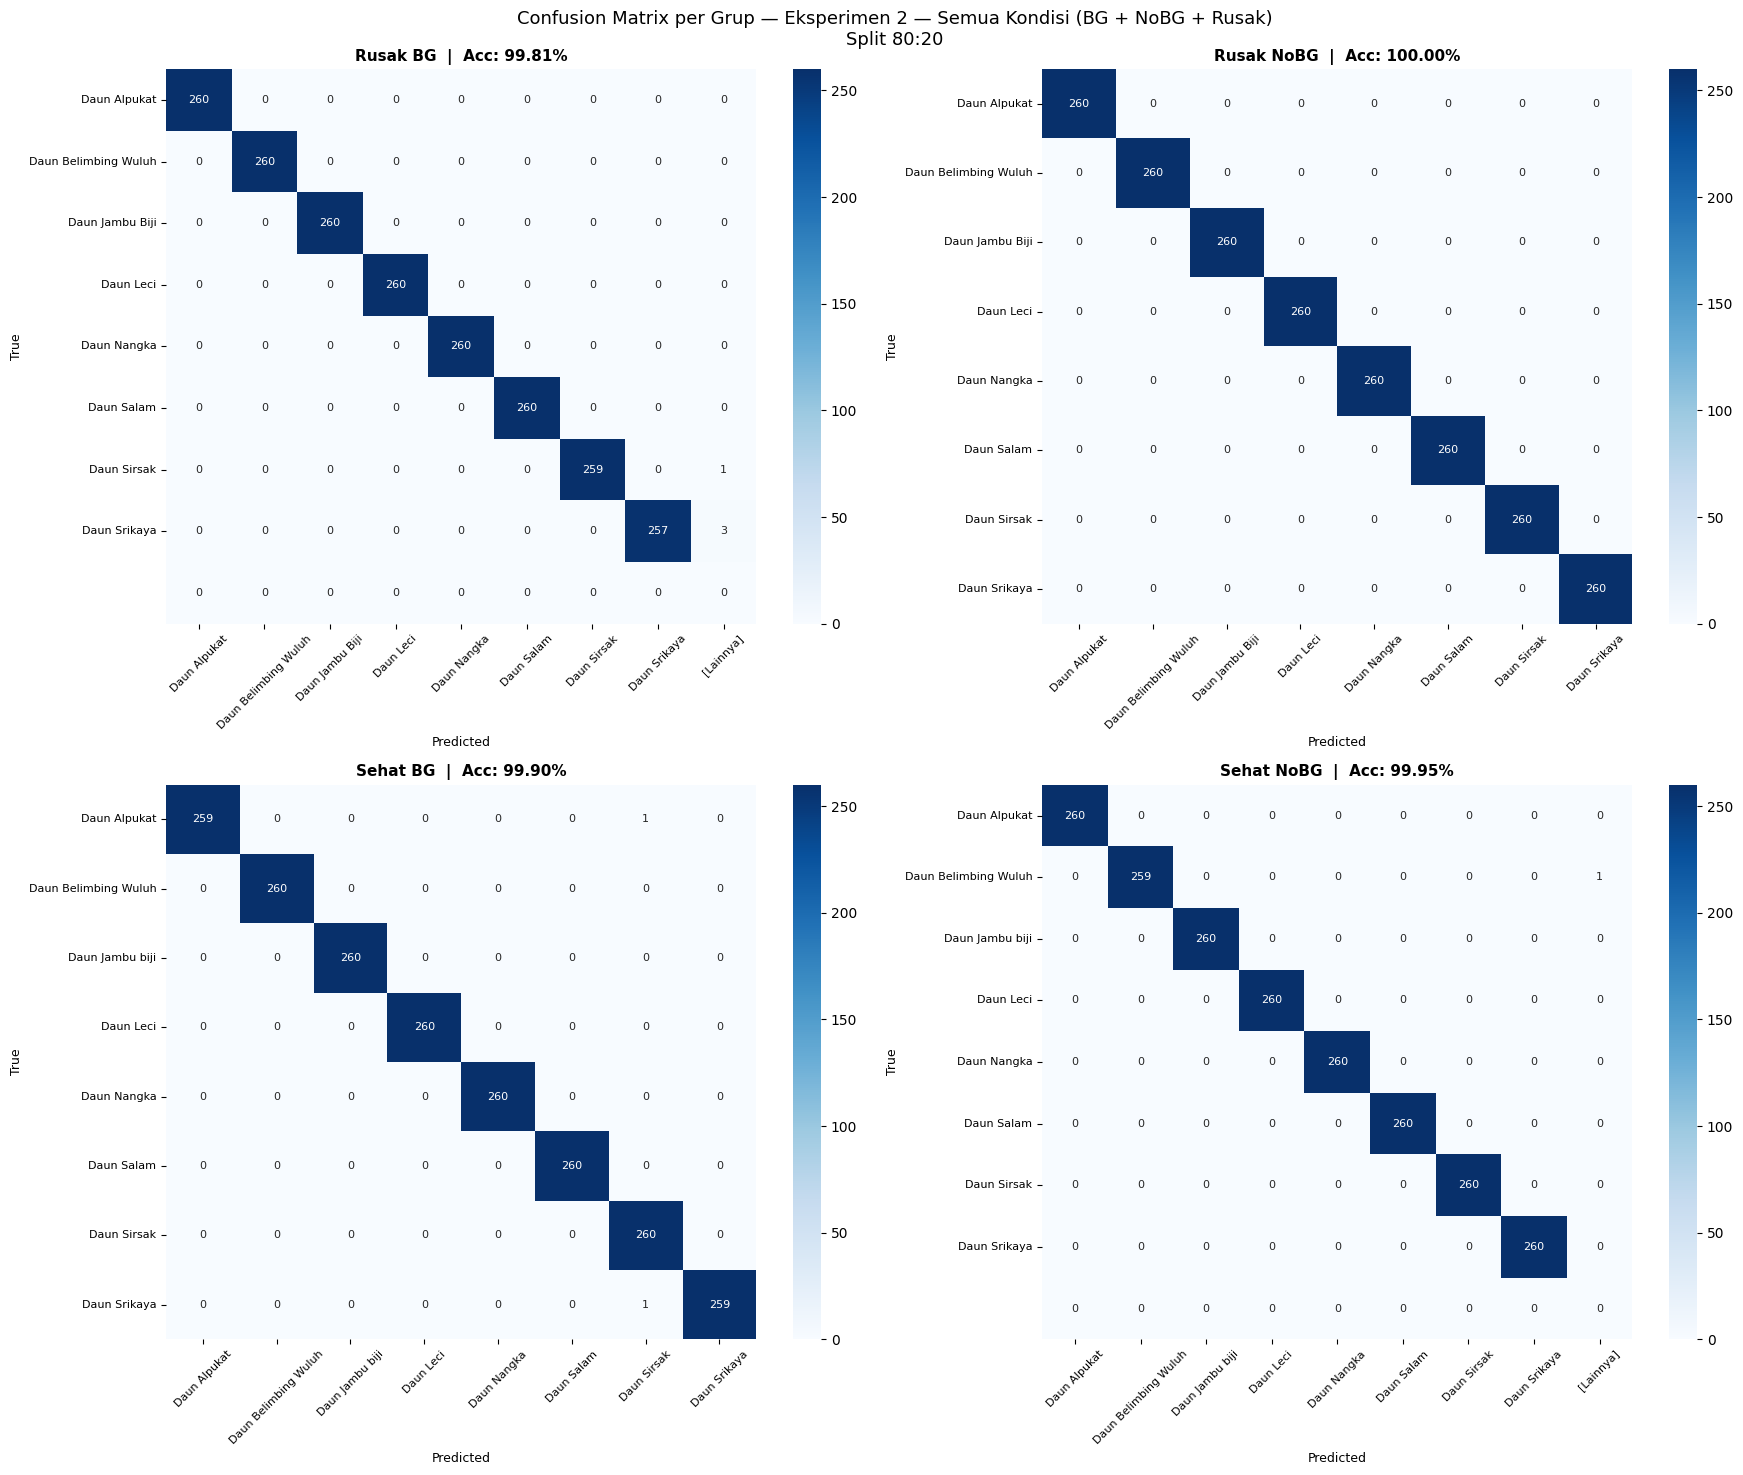

  Saved -> results_exp2_80.json

EKSPERIMEN 2 — SEMUA KONDISI (BG + NOBG + RUSAK) | Split 70:30
Kelas: 32 | Train: 29120 | Val: 12480
  Epoch 1/30  train_loss=2.1286  train_acc=0.7907  val_loss=1.4862  val_acc=0.8724
  Epoch 2/30  train_loss=1.0157  train_acc=0.9534  val_loss=0.9143  val_acc=0.9351
  Epoch 3/30  train_loss=0.6190  train_acc=0.9711  val_loss=0.6479  val_acc=0.9612
  Epoch 4/30  train_loss=0.4202  train_acc=0.9788  val_loss=0.4868  val_acc=0.9717
  Epoch 5/30  train_loss=0.3050  train_acc=0.9843  val_loss=0.3323  val_acc=0.9830
  Epoch 6/30  train_loss=0.2375  train_acc=0.9861  val_loss=0.3100  val_acc=0.9812
  Epoch 7/30  train_loss=0.1895  train_acc=0.9887  val_loss=0.2400  val_acc=0.9861
  Epoch 8/30  train_loss=0.1580  train_acc=0.9891  val_loss=0.1805  val_acc=0.9909
  Epoch 9/30  train_loss=0.1317  train_acc=0.9913  val_loss=0.1756  val_acc=0.9893
  Epoch 10/30  train_loss=0.1155  train_acc=0.9919  val_loss=0.1322  val_acc=0.9941
  Epoch 11/30  train_loss=0.0992  t

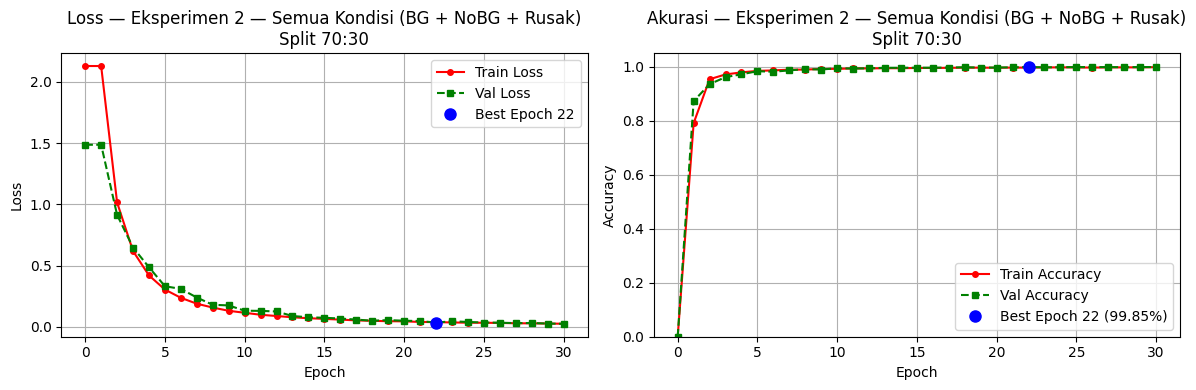

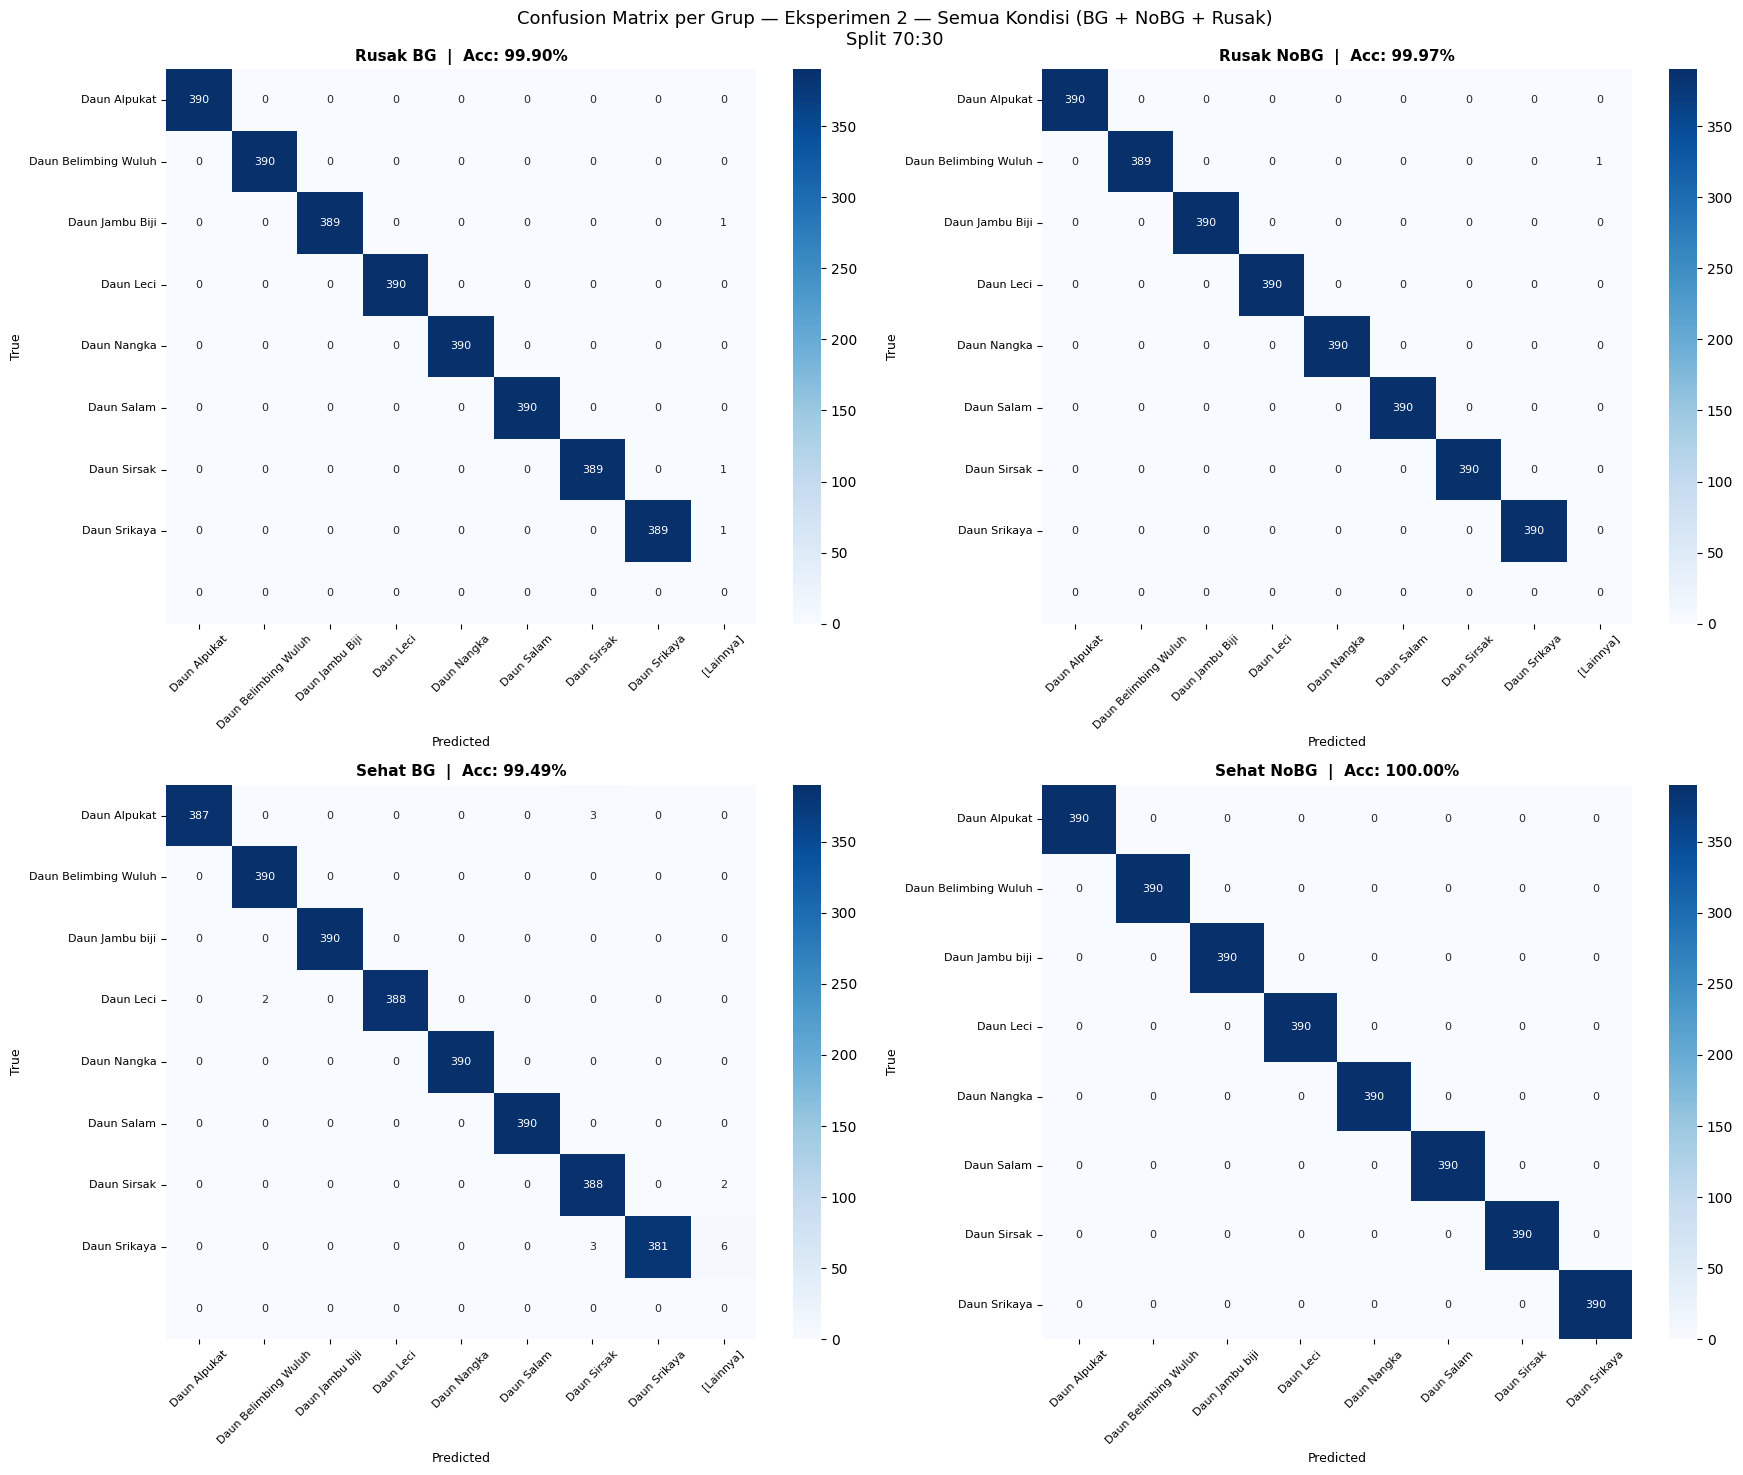

  Saved -> results_exp2_70.json


In [18]:
# Jalankan Eksperimen 2 (semua kondisi: sehat + rusak)
for ratio in [0.8, 0.7]:
    train_and_evaluate(
        exp_tag="exp2",
        exp_label="Eksperimen 2 — Semua Kondisi (BG + NoBG + Rusak)",
        include_rusak=True,
        split_ratio=ratio,
    )

## 7. Ringkasan Hasil

In [19]:
print("=== MODEL FILES ===")
for f in sorted(MODEL_DIR.glob("*.pth")):
    print(f"  {f.name}")

print("\n=== RESULT JSON ===")
for f in sorted(RESULT_DIR.glob("*.json")):
    try:
        text = f.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        text = f.read_text(encoding="cp1252")
    data = json.loads(text)
    acc  = data.get("final_val_accuracy", data.get("best_val_accuracy", "N/A"))
    tag  = data.get("tag", f.stem)
    print(f"  {f.name:<45} val_acc={acc}  [{tag}]")

print("\n=== PLOTS ===")
for f in sorted(RESULT_DIR.glob("*.png")):
    print(f"  {f.name}")


=== MODEL FILES ===
  shufflenet_exp1_70.pth
  shufflenet_exp1_80.pth
  shufflenet_exp2_70.pth
  shufflenet_exp2_80.pth

=== RESULT JSON ===
  results_exp1_70.json                          val_acc=0.9995  [exp1]
  results_exp1_80.json                          val_acc=0.999  [exp1]
  results_exp2_70.json                          val_acc=0.9984  [exp2]
  results_exp2_80.json                          val_acc=0.9992  [exp2]

=== PLOTS ===
  cm_split_exp1_70.png
  cm_split_exp1_80.png
  cm_split_exp2_70.png
  cm_split_exp2_80.png
  plot_exp1_70.png
  plot_exp1_80.png
  plot_exp2_70.png
  plot_exp2_80.png


## 8. Evaluasi TEST SET Independen + Perbandingan Validasi vs Test

⚠️ **Bedakan dua jenis metrik:**

| | Sumber data | Dihitung di | Sifat |
|---|---|---|---|
| **VALIDASI** | split validasi dari `final` + `final bg` | `train_and_evaluate` (Eksperimen 1/2) | Untuk monitoring & best epoch — **cenderung optimistis** karena berasal dari pool augmentasi yang sama dengan data latih |
| **TEST** | `data/train_combined` (independen, NoBG) | **sel ini** | Belum pernah dilihat model — **indikator generalisasi sebenarnya** |

Sel di bawah hanya **mengevaluasi weight yang sudah dilatih** (`shufflenet_exp{1,2}_{70,80}.pth`) — **tidak melatih ulang dan tidak mengubah logika training**. Jalankan setelah Eksperimen 1 & 2 selesai. Untuk ganti sumber test, ubah satu baris `TEST_DIR`.

**Aturan pemetaan test:** `data/train_combined` seluruhnya NoBG → ground-truth dipetakan ke kelas `… NoBG`; ruang prediksi tetap semua kelas (prediksi ke kelas BG dihitung salah). Folder **Mangga** dilewati (tak ada di kelas model); untuk **exp1** folder rusak juga dilewati.

**Output:**
- Metrik TEST per model + **selisih akurasi Validasi − Test** (gap = indikasi overfitting)
- Confusion matrix TEST: `results/cm_test_{tag}.png` (judul diawali `[TEST]`)
- `results/results_test_{tag}.json` (memuat `validation_accuracy` & `test_accuracy` sekaligus; `test_dir` mencatat sumber data)
- Tabel perbandingan Validasi vs Test untuk keempat model


Eksperimen 1 — Sehat (BG + NoBG) | split 80:20
  Test: 800 gambar dari test | folder dipakai=8 dilewati=10
  Dilewati: Daun Alpukat Rusak, Daun Belimbing Wuluh Rusak, Daun Jambu Biji Rusak, Daun Leci Rusak, Daun Mangga, Daun Mangga Rusak, Daun Nangka Rusak, Daun Salam Rusak, Daun Sirsak Rusak, Daun Srikaya Rusak
  [VALIDASI] (final+final bg, saat training)     Acc=0.999  F1=0.999
  [TEST]     (test, independen)        Acc=0.9513  Prec=0.9611  Rec=0.9513  F1=0.9523
  Selisih akurasi (Validasi - Test) = +0.0477   (makin besar = makin overfit)


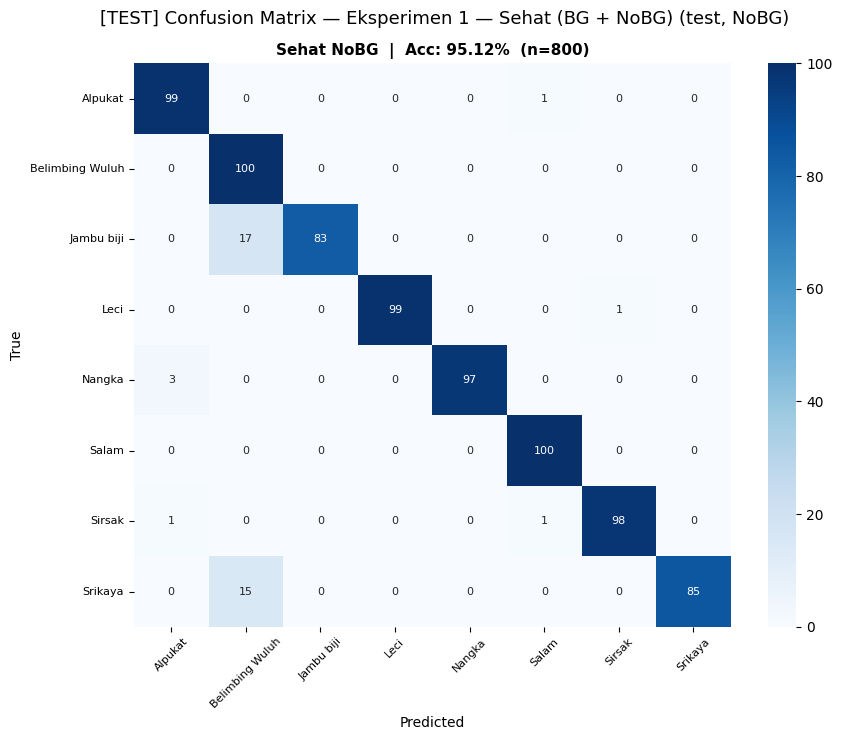


Eksperimen 1 — Sehat (BG + NoBG) | split 70:30
  Test: 800 gambar dari test | folder dipakai=8 dilewati=10
  Dilewati: Daun Alpukat Rusak, Daun Belimbing Wuluh Rusak, Daun Jambu Biji Rusak, Daun Leci Rusak, Daun Mangga, Daun Mangga Rusak, Daun Nangka Rusak, Daun Salam Rusak, Daun Sirsak Rusak, Daun Srikaya Rusak
  [VALIDASI] (final+final bg, saat training)     Acc=0.9995  F1=0.9995
  [TEST]     (test, independen)        Acc=0.9563  Prec=0.9660  Rec=0.9563  F1=0.9573
  Selisih akurasi (Validasi - Test) = +0.0433   (makin besar = makin overfit)


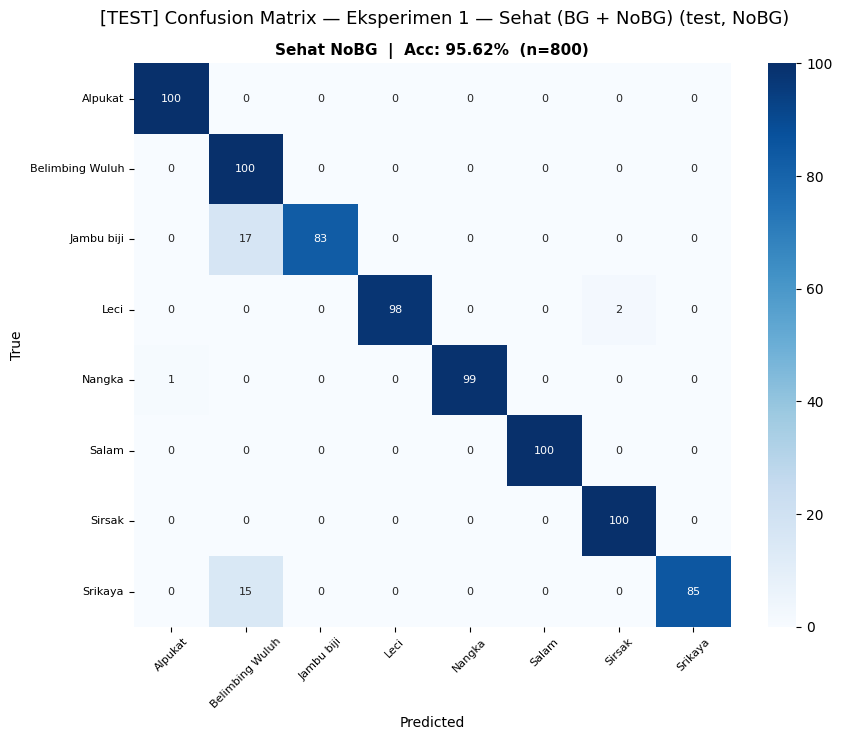


Eksperimen 2 — Semua Kondisi (BG + NoBG + Rusak) | split 80:20
  Test: 1600 gambar dari test | folder dipakai=16 dilewati=2
  Dilewati: Daun Mangga, Daun Mangga Rusak
  [VALIDASI] (final+final bg, saat training)     Acc=0.9992  F1=0.9992
  [TEST]     (test, independen)        Acc=0.9081  Prec=0.9191  Rec=0.9081  F1=0.9099
  Selisih akurasi (Validasi - Test) = +0.0911   (makin besar = makin overfit)


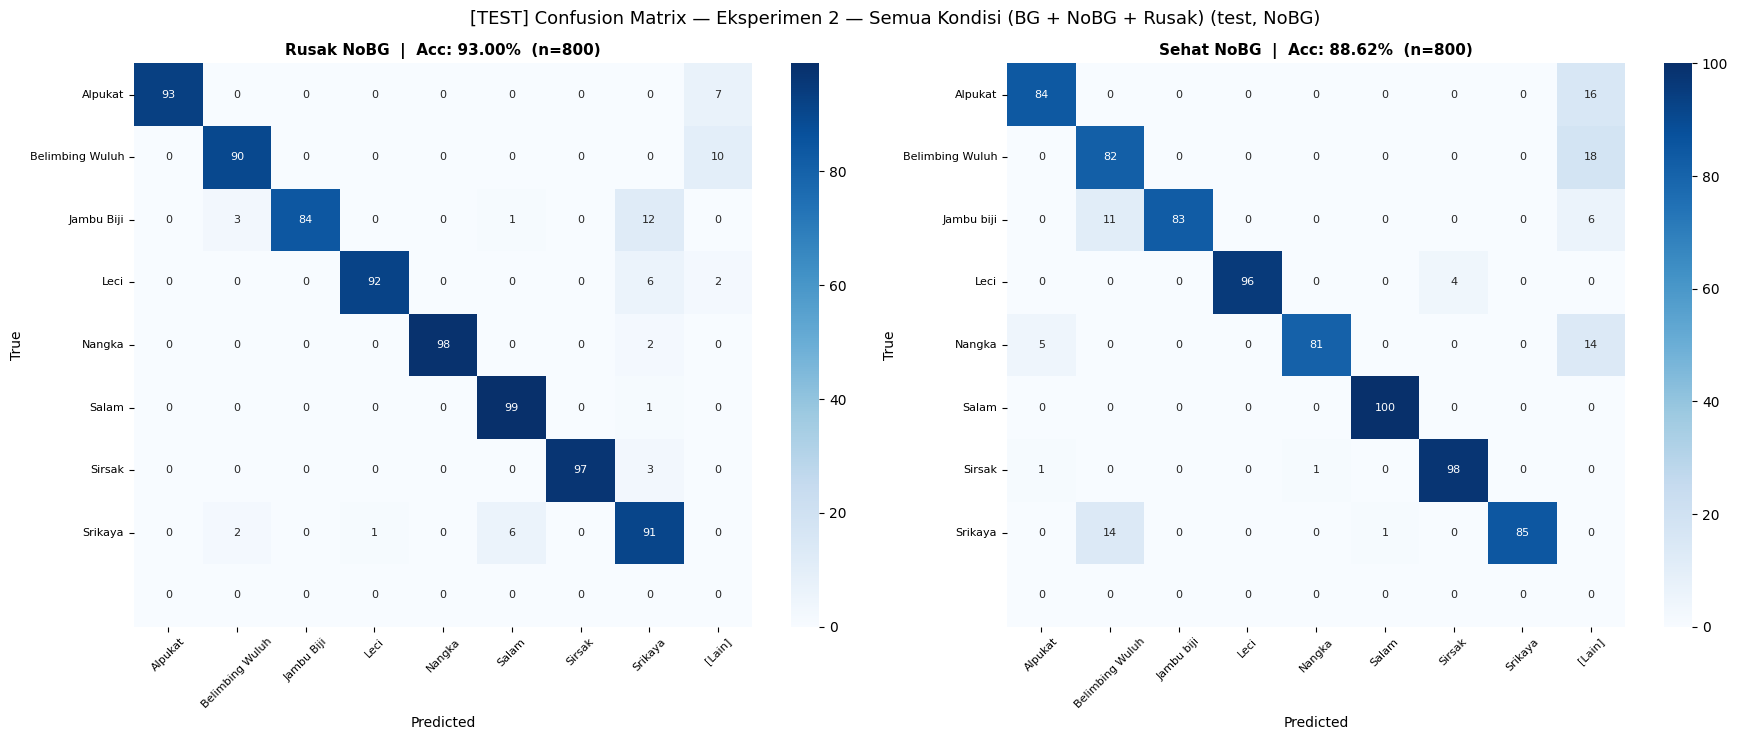


Eksperimen 2 — Semua Kondisi (BG + NoBG + Rusak) | split 70:30
  Test: 1600 gambar dari test | folder dipakai=16 dilewati=2
  Dilewati: Daun Mangga, Daun Mangga Rusak
  [VALIDASI] (final+final bg, saat training)     Acc=0.9984  F1=0.9984
  [TEST]     (test, independen)        Acc=0.9137  Prec=0.9249  Rec=0.9137  F1=0.9158
  Selisih akurasi (Validasi - Test) = +0.0847   (makin besar = makin overfit)


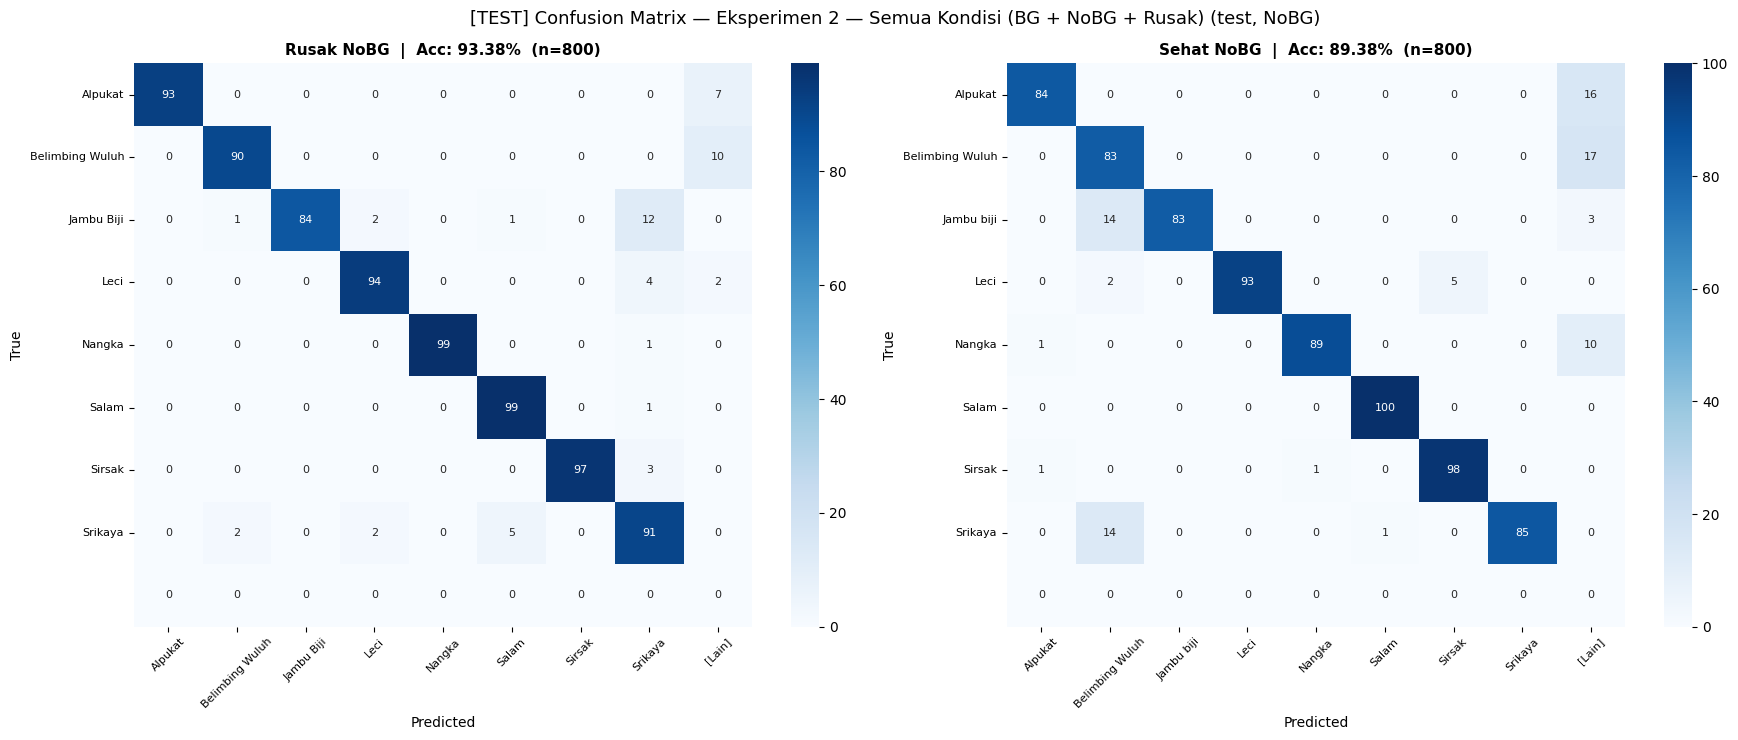



PERBANDINGAN VALIDASI vs TEST (test = data/test, NoBG)
Model        Val_Acc  Test_Acc   Selisih   Val_F1  Test_F1  N_test
exp1_80       0.9990    0.9513   +0.0477   0.9990   0.9523     800
exp1_70       0.9995    0.9563   +0.0433   0.9995   0.9573     800
exp2_80       0.9992    0.9081   +0.0911   0.9992   0.9099    1600
exp2_70       0.9984    0.9137   +0.0847   0.9984   0.9158    1600

Catatan: Val_Acc berasal dari results_{tag}.json (validasi saat training);
Test_Acc dihitung di sel ini pada data/test. Selisih besar = overfitting.


In [20]:
# ── Evaluasi TEST SET (data/train_combined) + perbandingan VALIDASI vs TEST ───
# PENTING — bedakan dua jenis metrik:
#   • VALIDASI : metrik yang dicetak/disimpan oleh train_and_evaluate (Eksperimen 1/2).
#                Dihitung pada SPLIT VALIDASI dari final + final bg. Dipakai untuk
#                monitoring & pemilihan best epoch -> cenderung optimistis.
#   • TEST     : metrik pada DATA TEST INDEPENDEN (data/testing) yang TIDAK
#                dipakai saat training -> indikator generalisasi sebenarnya.
# Sel ini hanya MENGEVALUASI weight yang sudah ada; tidak melatih ulang & tidak
# mengubah logika training. Aman dijalankan setelah Eksperimen 1/2 selesai.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

TEST_DIR       = DATA_DIR / "test"   # <- sumber data testing (NoBG)
transform_test = transform_val                  # tanpa augmentasi (resize + normalize saja)
IMG_EXT        = {".jpg", ".jpeg", ".png"}

# TEST_DIR seluruhnya NoBG. Nama folder dipetakan ke spesies model lewat keyword.
SPECIES_KEYWORDS = [
    (("alpukat",),                          "alpukat"),
    (("belimbing", "blbm", "wuluh", "wlh"), "belimbing wuluh"),
    (("jambu",),                            "jambu biji"),
    (("leci",),                             "leci"),
    (("mangga",),                           "mangga"),      # tak dikenal model -> dilewati
    (("nangka",),                           "nangka"),
    (("salam",),                            "salam"),
    (("sirsak",),                           "sirsak"),
    (("srikaya",),                          "srikaya"),
]

def _species_key(cn: str) -> str:
    return _species_name(cn).replace("Daun", "").strip().lower()

def parse_test_folder(name: str):
    low = name.lower()
    sp  = next((canon for keys, canon in SPECIES_KEYWORDS if any(k in low for k in keys)), None)
    return sp, (("rusak" in low) or ("rsk" in low))

class TestDS(Dataset):
    def __init__(self, samples, tf): self.samples, self.tf = samples, tf
    def __len__(self):  return len(self.samples)
    def __getitem__(self, i):
        path, label = self.samples[i]
        return self.tf(Image.open(path).convert("RGB")), label

def build_test_samples(class_names):
    # Ground-truth dipetakan ke kelas "... NoBG"; ruang prediksi tetap semua kelas.
    nobg_map = {(_species_key(cn), "Rusak" in cn): i
                for i, cn in enumerate(class_names) if cn.endswith("NoBG")}
    samples, mapped, skipped = [], {}, {}
    for folder in sorted(TEST_DIR.iterdir()):
        if not folder.is_dir():
            continue
        sp, rusak = parse_test_folder(folder.name)
        imgs = [p for p in folder.iterdir() if p.suffix.lower() in IMG_EXT]
        key  = (sp, rusak)
        if sp is not None and key in nobg_map:
            samples.extend((str(p), nobg_map[key]) for p in imgs)
            mapped[folder.name] = (class_names[nobg_map[key]], len(imgs))
        else:
            skipped[folder.name] = len(imgs)
    return samples, mapped, skipped

def plot_test_cm(y_true, y_pred, class_names, exp_tag, train_pct, exp_label):
    group_of = {cn: _get_group(cn) for cn in class_names}
    present  = sorted({group_of[class_names[t]] for t in set(y_true)})
    n_cols   = min(2, len(present))
    n_rows   = (len(present) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*9, n_rows*7.5), squeeze=False)
    axes = axes.flatten()
    for ax_idx, group in enumerate(present):
        grp_classes  = [cn for cn in class_names if group_of[cn] == group]
        grp_idx_map  = {class_names.index(cn): i for i, cn in enumerate(grp_classes)}
        species_lbls = [_species_name(cn).replace("Daun", "").strip() for cn in grp_classes]
        n = len(grp_classes)
        mask     = [i for i, t in enumerate(y_true) if t in grp_idx_map]
        sub_true = [grp_idx_map[y_true[i]] for i in mask]
        sub_pred = [grp_idx_map.get(y_pred[i], n) for i in mask]
        has_other = any(p == n for p in sub_pred)
        n_pred    = n + 1 if has_other else n
        col_lbls  = species_lbls + (["[Lain]"] if has_other else [])
        cm  = confusion_matrix(sub_true, sub_pred, labels=list(range(n_pred)))
        acc = sum(t == p for t, p in zip(sub_true, sub_pred)) / len(sub_true) if sub_true else 0
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=col_lbls,
                    yticklabels=species_lbls, ax=axes[ax_idx], annot_kws={"size": 8})
        axes[ax_idx].set_title(f"{group}  |  Acc: {acc:.2%}  (n={len(sub_true)})",
                               fontsize=11, fontweight="bold")
        axes[ax_idx].set_xlabel("Predicted"); axes[ax_idx].set_ylabel("True")
        axes[ax_idx].tick_params(axis="x", rotation=45, labelsize=8)
        axes[ax_idx].tick_params(axis="y", rotation=0,  labelsize=8)
    for j in range(len(present), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"[TEST] Confusion Matrix — {exp_label} ({TEST_DIR.name}, NoBG)", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f"cm_test_{exp_tag}_{train_pct}.png", dpi=150, bbox_inches="tight")
    plt.show()

def evaluate_on_testset(exp_tag, train_pct):
    res = json.loads((RESULT_DIR / f"results_{exp_tag}_{train_pct}.json").read_text(encoding="utf-8"))
    class_names, exp_label, num_classes = res["class_names"], res["experiment"], len(res["class_names"])
    # Metrik VALIDASI (dari training, pada split val final+final bg)
    val_acc, val_f1 = res.get("accuracy"), res.get("f1_weighted")

    model = models.shufflenet_v2_x1_0(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load(MODEL_DIR / f"shufflenet_{exp_tag}_{train_pct}.pth",
                                     map_location=DEVICE))
    model.to(DEVICE).eval()

    samples, mapped, skipped = build_test_samples(class_names)
    loader = DataLoader(TestDS(samples, transform_test), batch_size=64, shuffle=False, num_workers=0)
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            _, preds = torch.max(model(x.to(DEVICE)), 1)
            y_true.extend(y.numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())

    # Metrik TEST (data/train_combined, independen)
    t_acc  = accuracy_score(y_true, y_pred)
    t_prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    t_rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    t_f1   = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    report = classification_report(y_true, y_pred, labels=list(range(num_classes)),
                                   target_names=class_names, output_dict=True, zero_division=0)

    gap = (val_acc - t_acc) if val_acc is not None else None
    print(f"\n{'='*64}\n{exp_label} | split {train_pct}:{100-train_pct}")
    print(f"  Test: {len(samples)} gambar dari {TEST_DIR.name} | "
          f"folder dipakai={len(mapped)} dilewati={len(skipped)}")
    if skipped:
        print(f"  Dilewati: {', '.join(sorted(skipped))}")
    print(f"  [VALIDASI] (final+final bg, saat training)     Acc={val_acc}  F1={val_f1}")
    print(f"  [TEST]     ({TEST_DIR.name}, independen)        "
          f"Acc={t_acc:.4f}  Prec={t_prec:.4f}  Rec={t_rec:.4f}  F1={t_f1:.4f}")
    if gap is not None:
        print(f"  Selisih akurasi (Validasi - Test) = {gap:+.4f}   (makin besar = makin overfit)")

    plot_test_cm(y_true, y_pred, class_names, exp_tag, train_pct, exp_label)

    (RESULT_DIR / f"results_test_{exp_tag}_{train_pct}.json").write_text(json.dumps({
        "experiment": exp_label, "tag": exp_tag, "split_model": f"{train_pct}:{100-train_pct}",
        "eval_type": "TEST (independen)", "test_dir": str(TEST_DIR),
        "num_classes": num_classes, "n_test_images": len(samples),
        "folders_used": mapped, "folders_skipped": skipped,
        "validation_accuracy": val_acc, "validation_f1_weighted": val_f1,
        "test_accuracy": round(t_acc, 4), "test_precision_weighted": round(t_prec, 4),
        "test_recall_weighted": round(t_rec, 4), "test_f1_weighted": round(t_f1, 4),
        "classification_report": report,
    }, indent=2, ensure_ascii=False), encoding="utf-8")
    return {"model": f"{exp_tag}_{train_pct}", "val_acc": val_acc, "val_f1": val_f1,
            "test_acc": t_acc, "test_f1": t_f1, "gap": gap, "n": len(samples)}


_rows = [evaluate_on_testset(t, p) for t, p in [("exp1", 80), ("exp1", 70), ("exp2", 80), ("exp2", 70)]]

print(f"\n\n{'='*72}\nPERBANDINGAN VALIDASI vs TEST (test = data/{TEST_DIR.name}, NoBG)\n{'='*72}")
print(f"{'Model':<11}{'Val_Acc':>9}{'Test_Acc':>10}{'Selisih':>10}{'Val_F1':>9}{'Test_F1':>9}{'N_test':>8}")
for r in _rows:
    va  = f"{r['val_acc']:.4f}" if r['val_acc'] is not None else "  -  "
    vf  = f"{r['val_f1']:.4f}"  if r['val_f1']  is not None else "  -  "
    gp  = f"{r['gap']:+.4f}"    if r['gap']     is not None else "  -  "
    print(f"{r['model']:<11}{va:>9}{r['test_acc']:>10.4f}{gp:>10}{vf:>9}{r['test_f1']:>9.4f}{r['n']:>8}")
print(f"\nCatatan: Val_Acc berasal dari results_{{tag}}.json (validasi saat training);"
      f"\nTest_Acc dihitung di sel ini pada data/{TEST_DIR.name}. Selisih besar = overfitting.")
